In [1]:
!pip install pytorch-tabnet shap imbalanced-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, RocCurveDisplay)
from imblearn.over_sampling import SMOTE
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import shap
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded ✓")
print(f"PyTorch version: {torch.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 968.6 kB/s eta 0:00:00
All libraries loaded ✓
PyTorch version: 2.11.0+cpu


In [2]:
URL = ("https://raw.githubusercontent.com/IBM/"
       "employee-attrition-aif360/master/data/emp_attrition.csv")

df = pd.read_csv(URL)
print(f"Shape: {df.shape}")
print(f"\nAttrition breakdown:")
print(df['Attrition'].value_counts())
print(f"\nAttrition rate: {df['Attrition'].value_counts(normalize=True)['Yes']:.1%}")
df.head()

Shape: (1470, 35)

Attrition breakdown:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate: 16.1%


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# Cell 3 — Preprocessing

# Drop zero-variance and ID columns
drop_cols = ['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18']
df.drop(columns=drop_cols, inplace=True)

# Encode target
df['Attrition'] = (df['Attrition'] == 'Yes').astype(int)

# Identify feature types
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('Attrition')

print(f"Categorical features ({len(cat_cols)}): {cat_cols}")
print(f"\nNumeric features ({len(num_cols)}): {num_cols}")
print(f"\nMissing values: {df.isnull().sum().sum()}")

Categorical features (7): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Numeric features (23): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Missing values: 0


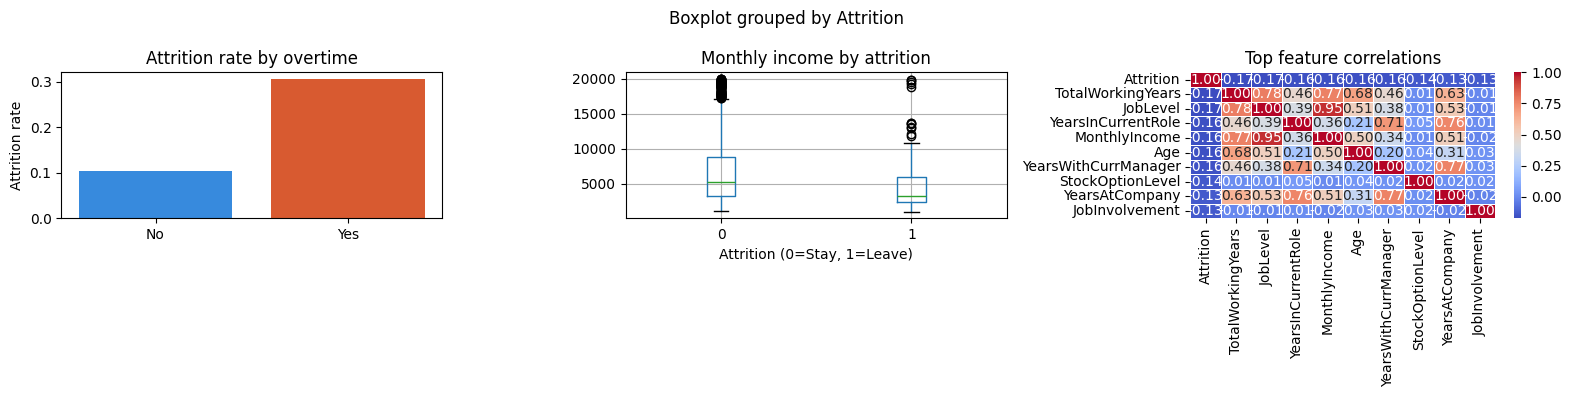

In [4]:
# Cell 4 — EDA

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Attrition rate by OverTime
ot = df.groupby('OverTime')['Attrition'].mean().reset_index()
axes[0].bar(ot['OverTime'], ot['Attrition'], color=['#378ADD','#D85A30'])
axes[0].set_title('Attrition rate by overtime')
axes[0].set_ylabel('Attrition rate')

# Monthly income distribution
df.boxplot(column='MonthlyIncome', by='Attrition', ax=axes[1])
axes[1].set_title('Monthly income by attrition')
axes[1].set_xlabel('Attrition (0=Stay, 1=Leave)')

# Correlation heatmap (numeric only)
corr = df[num_cols + ['Attrition']].corr()
top = corr['Attrition'].abs().sort_values(ascending=False).head(10).index
sns.heatmap(df[top].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=axes[2], linewidths=0.5)
axes[2].set_title('Top feature correlations')

plt.tight_layout()
plt.show()

In [5]:
# Cell 5 — Feature engineering

# Label encode categoricals
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numeric features
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_bal).value_counts().to_dict()}")
print(f"\nTrain size: {X_train_bal.shape}, Test size: {X_test.shape}")

Before SMOTE: {0: 986, 1: 190}
After SMOTE:  {0: 986, 1: 986}

Train size: (1972, 30), Test size: (294, 30)


In [13]:
# Cell 6 — PyTorch Dataset & Model

class HRDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_ds = HRDataset(X_train, y_train)
test_ds  = HRDataset(X_test, y_test)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64)

class AttritionMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.BatchNorm1d(64),
            nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x)

model = AttritionMLP(input_dim=X_train_bal.shape[1])
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 4,225


In [15]:
# Cell 7 — Training loop

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

EPOCHS = 100
LR = 3e-4  # lower LR

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-3)  # stronger regularization
pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Early stopping
best_auc, patience, wait = 0, 15, 0

# Move model to device
model.to(device)

train_losses = []
val_aucs = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b.unsqueeze(1))
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()

    model.eval()
    preds = []
    with torch.no_grad():
        for X_b, _ in test_loader:
            preds.extend(torch.sigmoid(model(X_b.to(device))).cpu().numpy())

    auc = roc_auc_score(y_test, preds)
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    val_aucs.append(auc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {avg_loss:.4f} | Val AUC: {auc:.4f}")

    # Early stopping
    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), 'best_model.pt')
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}. Best AUC: {best_auc:.4f}")
            break

# Load best weights
model.load_state_dict(torch.load('best_model.pt'))
print(f"\nFinal best AUC: {best_auc:.4f}")

Epoch  10 | Loss: 1.0802 | Val AUC: 0.7225
Epoch  20 | Loss: 0.9544 | Val AUC: 0.7663
Epoch  30 | Loss: 0.9274 | Val AUC: 0.7864
Epoch  40 | Loss: 0.8524 | Val AUC: 0.7989
Epoch  50 | Loss: 0.8403 | Val AUC: 0.8030
Epoch  60 | Loss: 0.8145 | Val AUC: 0.8044
Epoch  70 | Loss: 0.7702 | Val AUC: 0.8040

Early stopping at epoch 71. Best AUC: 0.8061

Final best AUC: 0.8061


FINAL MODEL PERFORMANCE

AUC-ROC: 0.7724
F1-Score: 0.4812
Precision: 0.3721
Recall: 0.6809

Classification Report:
              precision    recall  f1-score   support

        Stay       0.93      0.78      0.85       247
       Leave       0.37      0.68      0.48        47

    accuracy                           0.77       294
   macro avg       0.65      0.73      0.66       294
weighted avg       0.84      0.77      0.79       294


Confusion Matrix:
  True Negatives:  193   False Positives: 54
  False Negatives: 15   True Positives:  32


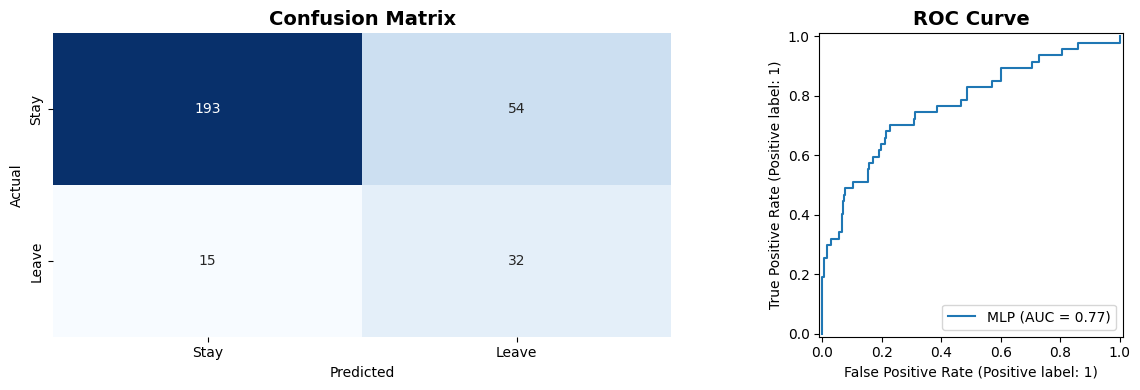

In [11]:
# Cell 8 — Final evaluation

model.eval()
all_probs, all_preds = [], []
with torch.no_grad():
    for X_b, _ in test_loader:
        probs = torch.sigmoid(model(X_b.to(device))).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend((probs >= 0.5).astype(int))

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, precision_score, recall_score
)

print("=" * 60)
print("FINAL MODEL PERFORMANCE")
print("=" * 60)
print(f"\nAUC-ROC: {roc_auc_score(y_test, all_probs):.4f}")
print(f"F1-Score: {f1_score(y_test, all_preds):.4f}")
print(f"Precision: {precision_score(y_test, all_preds):.4f}")
print(f"Recall: {recall_score(y_test, all_preds):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, all_preds, target_names=['Stay', 'Leave']))

# Confusion matrix
cm = confusion_matrix(y_test, all_preds)
print("\nConfusion Matrix:")
print(f"  True Negatives:  {cm[0,0]}   False Positives: {cm[0,1]}")
print(f"  False Negatives: {cm[1,0]}   True Positives:  {cm[1,1]}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay', 'Leave'], yticklabels=['Stay', 'Leave'],
            ax=ax1, cbar=False)
ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')

# ROC curve
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, all_probs, ax=ax2, name='MLP')
ax2.set_title('ROC Curve', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Top 15 Features by SHAP Importance:
                 Feature  Mean |SHAP|
                OverTime     0.365693
 EnvironmentSatisfaction     0.299507
         JobSatisfaction     0.297201
      NumCompaniesWorked     0.290319
 YearsSinceLastPromotion     0.284895
        DistanceFromHome     0.266852
          JobInvolvement     0.231807
    YearsWithCurrManager     0.229198
           MaritalStatus     0.224138
        StockOptionLevel     0.198822
                     Age     0.192379
       TotalWorkingYears     0.185122
       PercentSalaryHike     0.148036
         WorkLifeBalance     0.139176
RelationshipSatisfaction     0.134225


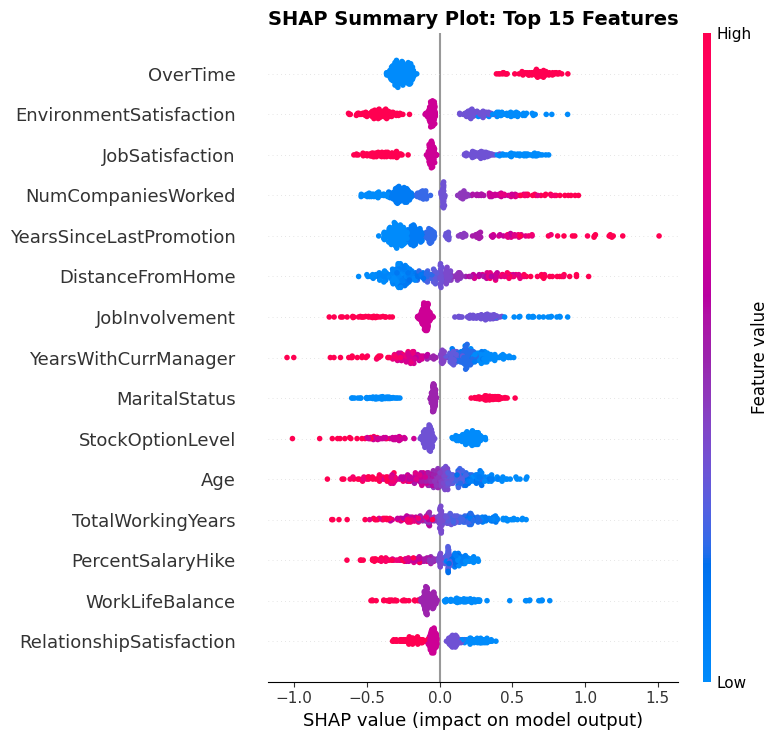


Individual predictions (SHAP Force Plot)

Example 1: High-risk employee (predicted prob: 0.799)


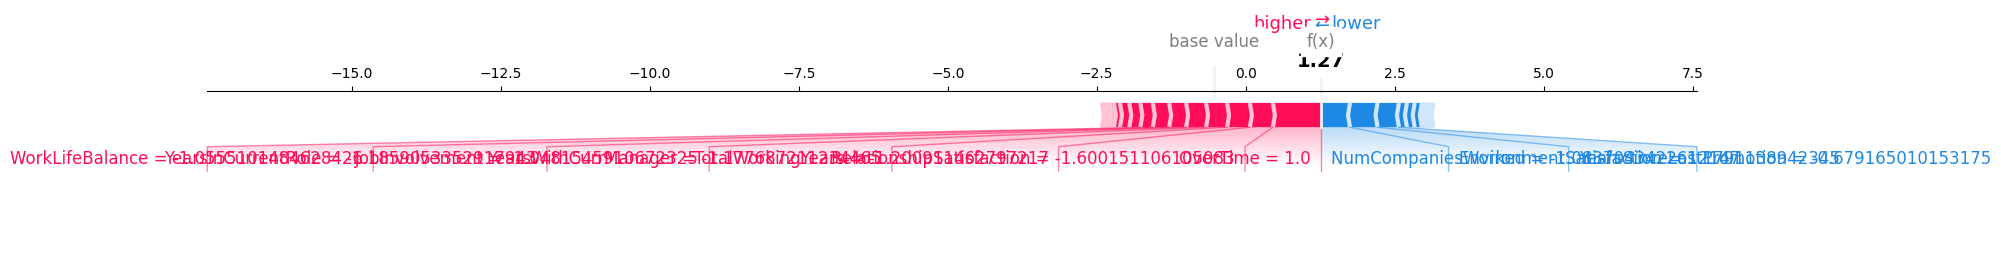


Example 2: Low-risk employee (predicted prob: 0.072)


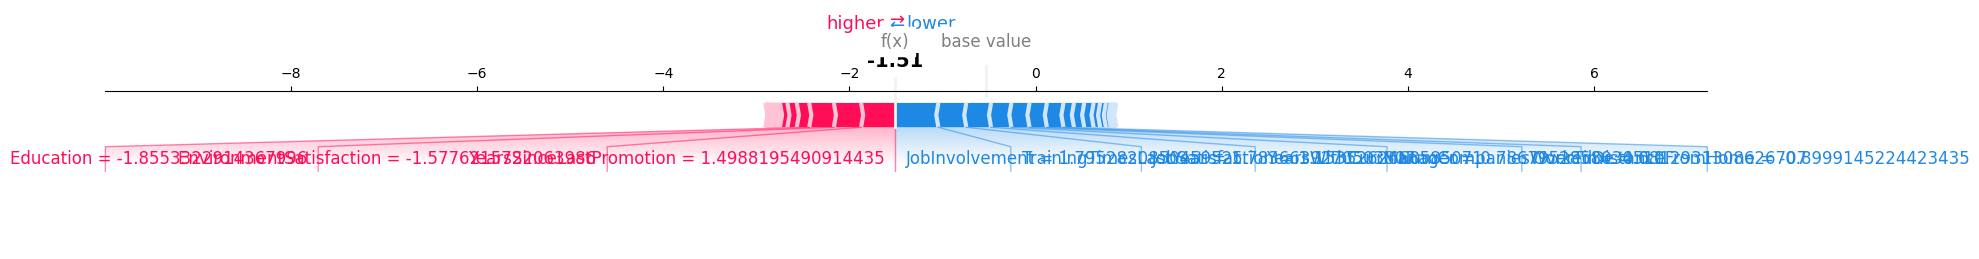

In [16]:
# Cell 10 — SHAP Explainability

import shap

# Convert test data to tensor for the model
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32).to(device)

# Create SHAP explainer
explainer = shap.DeepExplainer(model,
                                torch.tensor(X_train.values[:100].astype(np.float32)).to(device))
shap_values = explainer.shap_values(X_test_tensor)

# Convert to numpy
shap_values = np.array(shap_values).squeeze()

# Feature importance: mean absolute SHAP values
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)

print("\nTop 15 Features by SHAP Importance:")
print(feature_importance.head(15).to_string(index=False))

# Beeswarm plot
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title('SHAP Summary Plot: Top 15 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Force plot for a few examples
print("\n" + "="*60)
print("Individual predictions (SHAP Force Plot)")
print("="*60)

# Convert all_probs to a numpy array for comparison
all_probs_np = np.array(all_probs)

# High-risk employees (model predicts leave)
high_risk_idx = np.where(all_probs_np >= 0.7)[0]
if len(high_risk_idx) > 0:
    print(f"\nExample 1: High-risk employee (predicted prob: {all_probs_np[high_risk_idx[0]]:.3f})")
    shap.force_plot(explainer.expected_value,
                    shap_values[high_risk_idx[0]],
                    X_test.iloc[high_risk_idx[0]],
                    matplotlib=True, show=False)
    plt.tight_layout()
    plt.show()

# Low-risk employees (model predicts stay)
low_risk_idx = np.where(all_probs_np <= 0.3)[0]
if len(low_risk_idx) > 0:
    print(f"\nExample 2: Low-risk employee (predicted prob: {all_probs_np[low_risk_idx[0]]:.3f})")
    shap.force_plot(explainer.expected_value,
                    shap_values[low_risk_idx[0]],
                    X_test.iloc[low_risk_idx[0]],
                    matplotlib=True, show=False)
    plt.tight_layout()
    plt.show()